🚀 Загрузка статей с arXiv...
✓ Загружено 60 статей из категории math.CO
✓ Загружено 120 статей из категории math.ST
✓ Загружено 180 статей из категории math.LO
✓ Загружено 240 статей из категории math.OA
✓ Загружено 300 статей из категории math.PR
✓ Всего загружено 300 статей

🔍 Извлечение ключевых слов...
📊 Построение графа ключевых слов...
✓ Граф содержит 497 узлов и 5191 ребер

🎯 Кластеризация ключевых слов...
✓ Найдено 11 кластеров
✓ Модулярность кластеризации: 0.334

📈 Анализ центральности ключевых слов...
📚 Построение графа публикаций...
✓ Граф публикаций содержит 292 статей и 4555 связей

🔍 Похожие статьи на: 'Quiver superconformal index and giant gravitons: a...'
1. Сходство: 2 - On the Squared Distance Matrix of a Starlike Block Graph...
   Общие ключевые слова: matrix, mathcal...

2. Сходство: 1 - Polymatroidal ideals and their asymptotic syzygies...
   Общие ключевые слова: mathcal...

3. Сходство: 1 - Improved Bounds on Ultra-Log Concavity of the Grothendieck C...
   Общие 

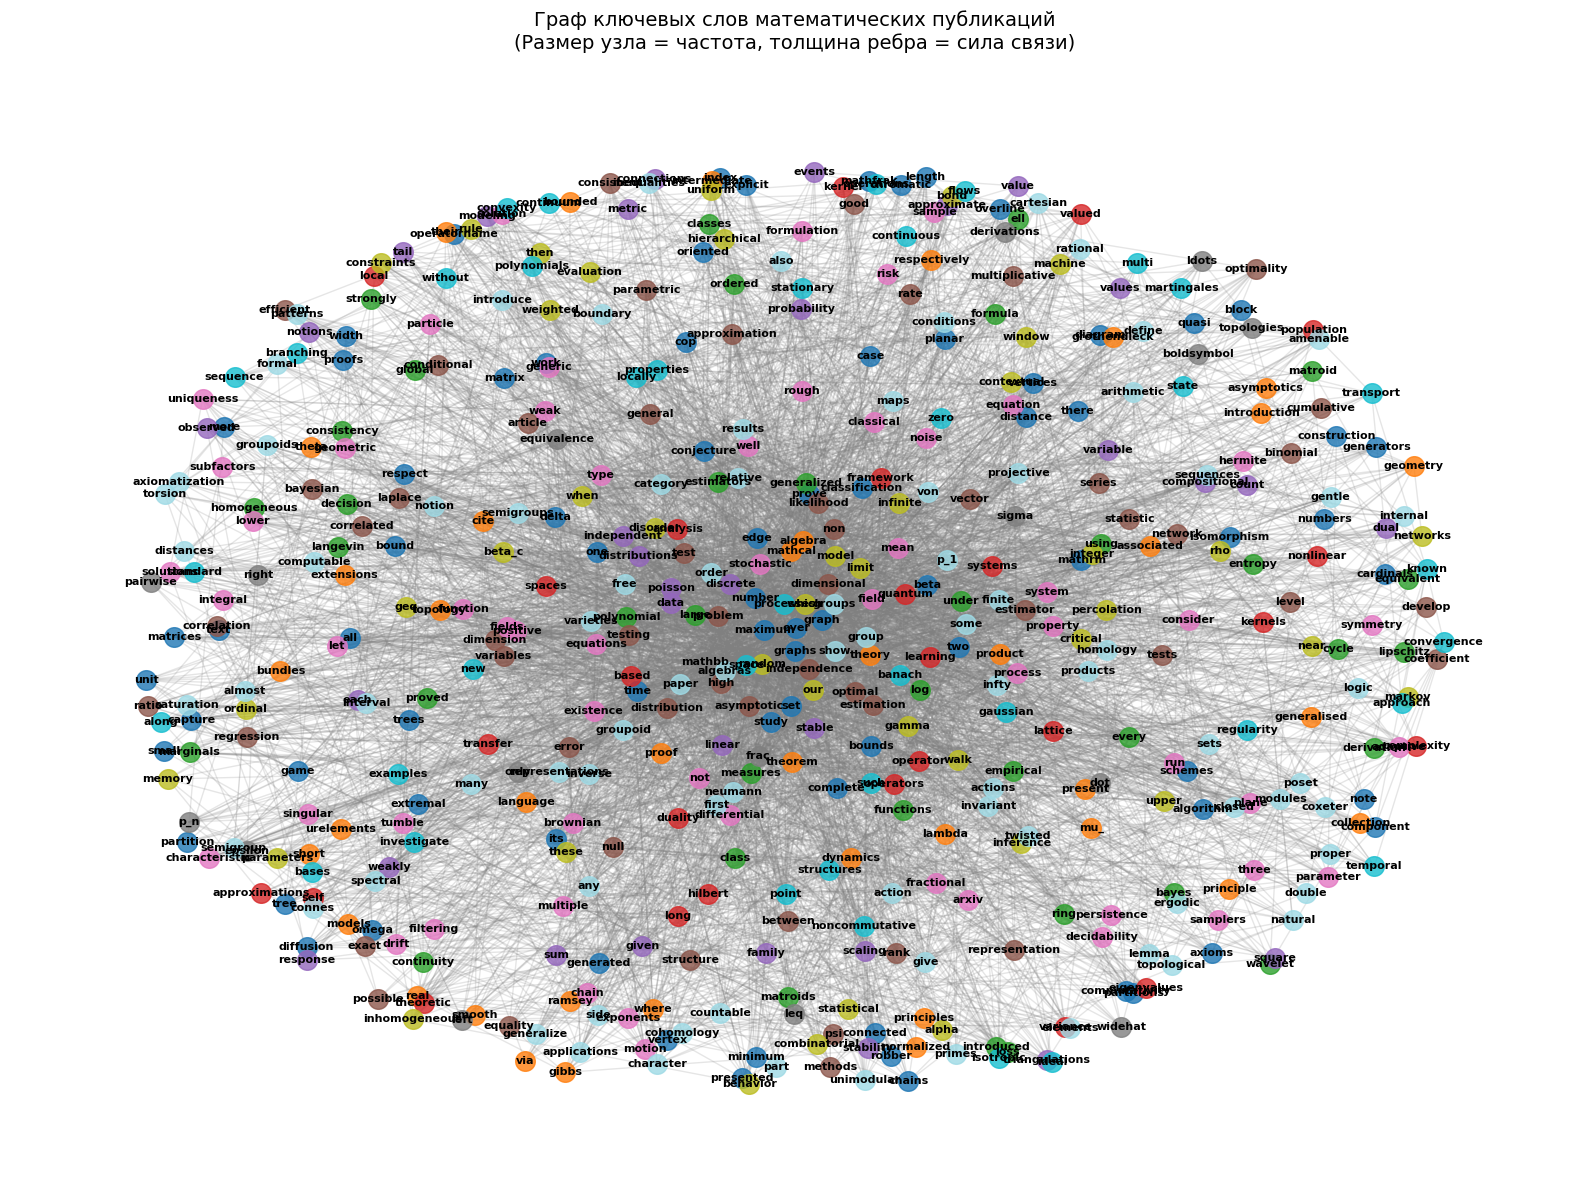

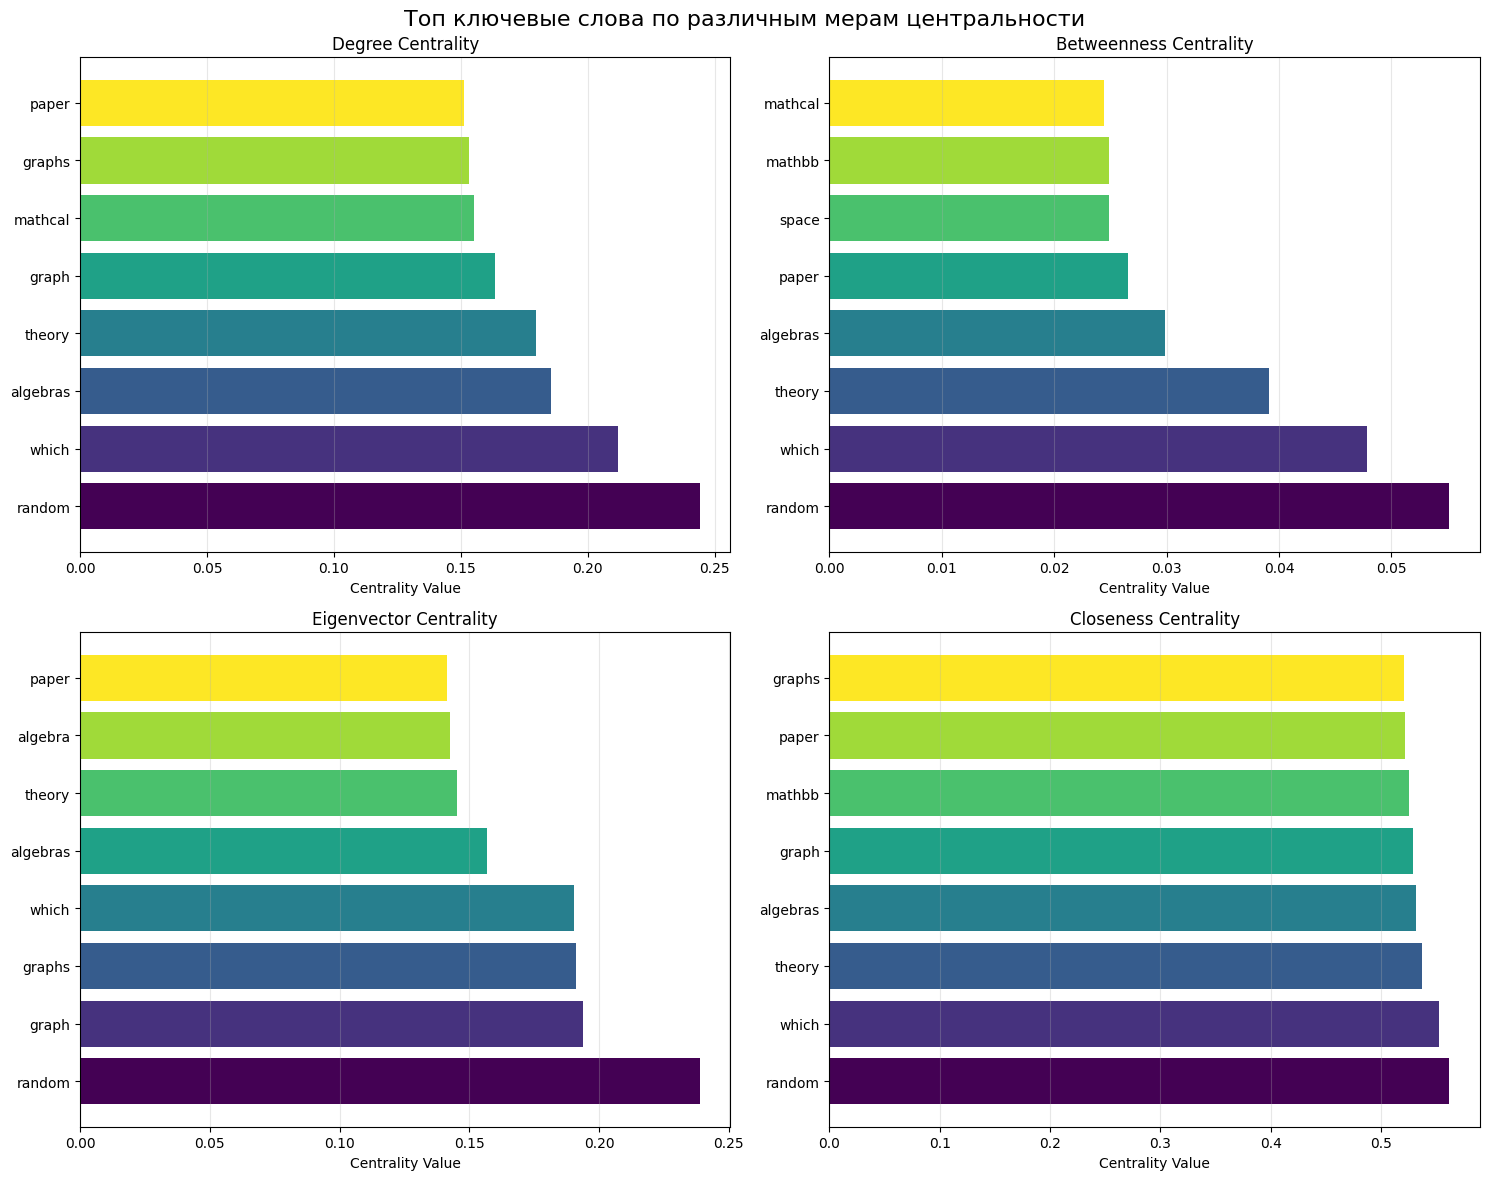


🎓 ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:

📊 КЛАСТЕРИЗАЦИЯ:
Модулярность 0.334 указывает на хорошее качество кластеризации
(значения > 0.3 считаются хорошими, > 0.7 - отличными)

⭐ ЦЕНТРАЛЬНОСТЬ:
Ключевое слово 'random' имеет наибольшую степень центральности
Это указывает на его фундаментальную роль в математических исследованиях

🔗 СВЯЗИ МЕЖДУ ОБЛАСТЯМИ:
Ключевые слова ['random', 'which', 'theory'] выступают мостами между разными областями


In [4]:
import requests
import xml.etree.ElementTree as ET
import time
import re
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Dict, Tuple, Set

SUBJECTS = {
    'math.CO': 'Combinatorics',
    'math.ST': 'Statistics Theory',
    'math.LO': 'Logic',
    'math.OA': 'Operator Algebras',
    'math.PR': 'Probability'
}


def fetch_arxiv_papers(subjects: Dict[str, str], max_results: int = 60) -> List[Dict]:
    """Загружает статьи с arXiv по указанным категориям"""
    base_url = "http://export.arxiv.org/api/query?"
    papers = []

    for category in subjects:
        query = f"search_query=cat:{category}&max_results={max_results}&sortBy=submittedDate&sortOrder=descending"
        url = base_url + query

        try:
            response = requests.get(url)
            response.raise_for_status()

            root = ET.fromstring(response.content)
            namespace = '{http://www.w3.org/2005/Atom}'

            for entry in root.findall(f'.//{namespace}entry'):
                paper = {
                    'id': entry.find(f'{namespace}id').text if entry.find(f'{namespace}id') is not None else '',
                    'title': entry.find(f'{namespace}title').text.strip() if entry.find(
                        f'{namespace}title') is not None else '',
                    'summary': entry.find(f'{namespace}summary').text.strip() if entry.find(
                        f'{namespace}summary') is not None else '',
                    'authors': [author.find(f'{namespace}name').text for author in entry.findall(f'{namespace}author')],
                    'categories': [cat.attrib.get('term', '') for cat in entry.findall(f'{namespace}category')],
                    'published': entry.find(f'{namespace}published').text if entry.find(
                        f'{namespace}published') is not None else ''
                }
                papers.append(paper)

            print(f"✓ Загружено {len(papers)} статей из категории {category}")
            time.sleep(1)

        except Exception as e:
            print(f"✗ Ошибка при загрузке категории {category}: {e}")

    return papers


def extract_keywords(text: str, max_words: int = 10) -> List[str]:
    """Извлекает ключевые слова из текста"""
    if not text:
        return []

    text = re.sub(r'[^\w\s]', ' ', text.lower())
    words = text.split()

    stop_words = {'the', 'and', 'of', 'in', 'to', 'a', 'an', 'for', 'on', 'with',
                  'by', 'as', 'at', 'from', 'that', 'this', 'is', 'are', 'was', 'were',
                  'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did',
                  'will', 'would', 'could', 'should', 'may', 'might', 'must', 'can'}

    filtered_words = [word for word in words if word not in stop_words and len(word) > 2]
    word_counts = Counter(filtered_words)

    return [word for word, count in word_counts.most_common(max_words)]


def process_papers_for_keywords(papers: List[Dict]) -> List[Dict]:
    """Обрабатывает статьи и извлекает ключевые слова"""
    for paper in papers:
        combined_text = paper['title'] + ' ' + paper['summary']
        paper['keywords'] = extract_keywords(combined_text)

    return papers


def build_keyword_graph(papers: List[Dict], min_cooccurrence: int = 2) -> nx.Graph:
    """Строит граф связей между ключевыми словами"""
    G = nx.Graph()
    keyword_papers = {}

    for paper in papers:
        for keyword in paper['keywords']:
            if keyword not in keyword_papers:
                keyword_papers[keyword] = set()
            keyword_papers[keyword].add(paper['id'])

    for keyword, paper_set in keyword_papers.items():
        if len(paper_set) >= min_cooccurrence:
            G.add_node(keyword, weight=len(paper_set), papers=paper_set)

    keywords_list = list(keyword_papers.keys())
    for i in range(len(keywords_list)):
        kw1 = keywords_list[i]
        if kw1 not in G:
            continue

        for j in range(i + 1, len(keywords_list)):
            kw2 = keywords_list[j]
            if kw2 not in G:
                continue

            common_papers = keyword_papers[kw1] & keyword_papers[kw2]
            if common_papers:
                weight = len(common_papers)
                G.add_edge(kw1, kw2, weight=weight)

    return G


def cluster_keywords(G: nx.Graph) -> Tuple[List[Set], float]:
    """Кластеризует ключевые слова и оценивает качество"""
    communities = nx.community.louvain_communities(G, weight='weight', seed=42)

    for cluster_id, community in enumerate(communities):
        for node in community:
            G.nodes[node]['cluster'] = cluster_id

    modularity = nx.community.modularity(G, communities, weight='weight')

    return communities, modularity


def analyze_centrality(G: nx.Graph, top_n: int = 10) -> Dict[str, Dict]:
    """Анализирует различные меры центральности"""
    centrality_measures = {
        'degree_centrality': nx.degree_centrality(G),
        'betweenness_centrality': nx.betweenness_centrality(G, weight='weight'),
        'eigenvector_centrality': nx.eigenvector_centrality(G, weight='weight', max_iter=1000),
        'closeness_centrality': nx.closeness_centrality(G)
    }

    top_keywords = {}
    for measure_name, centrality_dict in centrality_measures.items():
        sorted_items = sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:top_n]
        top_keywords[measure_name] = dict(sorted_items)

    return top_keywords


def build_paper_graph(papers: List[Dict]) -> nx.Graph:
    """Строит граф публикаций на основе общих ключевых слов"""
    G = nx.Graph()

    for paper in papers:
        G.add_node(paper['id'],
                   title=paper['title'][:50] + '...' if len(paper['title']) > 50 else paper['title'],
                   keywords=paper['keywords'])

    for i in range(len(papers)):
        paper1 = papers[i]
        for j in range(i + 1, len(papers)):
            paper2 = papers[j]

            common_keywords = set(paper1['keywords']) & set(paper2['keywords'])
            if common_keywords:
                weight = len(common_keywords)
                G.add_edge(paper1['id'], paper2['id'], weight=weight, common_keywords=list(common_keywords))

    return G


def find_similar_papers(paper_graph: nx.Graph, target_paper_id: str, top_k: int = 5) -> List[Tuple]:
    """Находит наиболее похожие статьи на заданную"""
    if target_paper_id not in paper_graph:
        return []

    similar_papers = []
    for neighbor in paper_graph.neighbors(target_paper_id):
        edge_data = paper_graph[target_paper_id][neighbor]
        similarity_score = edge_data['weight']
        similar_papers.append((neighbor, similarity_score, edge_data['common_keywords']))

    similar_papers.sort(key=lambda x: x[1], reverse=True)

    return similar_papers[:top_k]


def visualize_keyword_graph(G: nx.Graph, communities: List[Set]):
    """Визуализирует граф ключевых слов с кластерами"""
    plt.figure(figsize=(16, 12))

    pos = nx.spring_layout(G, k=1, iterations=50, seed=42)
    colors = plt.cm.tab20(np.linspace(0, 1, len(communities)))

    for i, community in enumerate(communities):
        nx.draw_networkx_nodes(G, pos, nodelist=list(community),
                               node_color=[colors[i]],
                               node_size=200, alpha=0.8)

    edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
    max_weight = max(edge_weights) if edge_weights else 1
    edge_alphas = [0.1 + 0.9 * (w / max_weight) for w in edge_weights]

    nx.draw_networkx_edges(G, pos, alpha=edge_alphas, width=1.0, edge_color='gray')

    important_nodes = [node for node, degree in dict(G.degree()).items() if degree > 3]
    labels = {node: node for node in important_nodes}
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')

    plt.title("Граф ключевых слов математических публикаций\n(Размер узла = частота, толщина ребра = сила связи)",
              fontsize=14, pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


def plot_centrality_results(centrality_results: Dict[str, Dict]):
    """Визуализирует результаты анализа центральности"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    for idx, (measure_name, data) in enumerate(centrality_results.items()):
        keywords = list(data.keys())
        values = list(data.values())

        axes[idx].barh(keywords, values, color=plt.cm.viridis(np.linspace(0, 1, len(keywords))))
        axes[idx].set_title(f'{measure_name.replace("_", " ").title()}')
        axes[idx].set_xlabel('Centrality Value')
        axes[idx].grid(axis='x', alpha=0.3)

    plt.suptitle('Топ ключевые слова по различным мерам центральности', fontsize=16)
    plt.tight_layout()
    plt.show()


def main():
    print("🚀 Загрузка статей с arXiv...")
    papers = fetch_arxiv_papers(SUBJECTS, max_results=60)
    print(f"✓ Всего загружено {len(papers)} статей\n")

    print("🔍 Извлечение ключевых слов...")
    papers = process_papers_for_keywords(papers)

    print("📊 Построение графа ключевых слов...")
    keyword_graph = build_keyword_graph(papers)
    print(f"✓ Граф содержит {keyword_graph.number_of_nodes()} узлов и {keyword_graph.number_of_edges()} ребер\n")

    print("🎯 Кластеризация ключевых слов...")
    communities, modularity = cluster_keywords(keyword_graph)
    print(f"✓ Найдено {len(communities)} кластеров")
    print(f"✓ Модулярность кластеризации: {modularity:.3f}\n")

    print("📈 Анализ центральности ключевых слов...")
    centrality_results = analyze_centrality(keyword_graph, top_n=8)

    print("📚 Построение графа публикаций...")
    paper_graph = build_paper_graph(papers)
    print(
        f"✓ Граф публикаций содержит {paper_graph.number_of_nodes()} статей и {paper_graph.number_of_edges()} связей\n")

    if papers:
        target_paper = papers[0]
        similar_papers = find_similar_papers(paper_graph, target_paper['id'])

        print(f"🔍 Похожие статьи на: '{target_paper['title'][:50]}...'")
        for i, (paper_id, score, common_kws) in enumerate(similar_papers, 1):
            paper_title = next((p['title'] for p in papers if p['id'] == paper_id), paper_id)
            print(f"{i}. Сходство: {score} - {paper_title[:60]}...")
            print(f"   Общие ключевые слова: {', '.join(common_kws[:3])}...\n")

    print("🎨 Визуализация результатов...")
    visualize_keyword_graph(keyword_graph, communities)
    plot_centrality_results(centrality_results)

    print("\n" + "=" * 60)
    print("🎓 ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:")
    print("=" * 60)

    print("\n📊 КЛАСТЕРИЗАЦИЯ:")
    print(f"Модулярность {modularity:.3f} указывает на хорошее качество кластеризации")
    print("(значения > 0.3 считаются хорошими, > 0.7 - отличными)")

    print("\n⭐ ЦЕНТРАЛЬНОСТЬ:")
    most_central = list(centrality_results['degree_centrality'].keys())[0]
    print(f"Ключевое слово '{most_central}' имеет наибольшую степень центральности")
    print("Это указывает на его фундаментальную роль в математических исследованиях")

    print("\n🔗 СВЯЗИ МЕЖДУ ОБЛАСТЯМИ:")
    bridge_keywords = list(centrality_results['betweenness_centrality'].keys())[:3]
    print(f"Ключевые слова {bridge_keywords} выступают мостами между разными областями")

    return {
        'papers': papers,
        'keyword_graph': keyword_graph,
        'paper_graph': paper_graph,
        'communities': communities,
        'modularity': modularity,
        'centrality': centrality_results
    }


if __name__ == "__main__":
    results = main()